Load all LDA maps and make an average one!

In [12]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_17aug, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import (
    JAL4_3rdSept,
    JAL4_19thSept,
    JAL4_11thSept,
    JAL4_28aug,
    JAL4_17aug,
)

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_2ndSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import (
    JAL6_shelt_4mar,
    JAL6_28mar,
    JAL6_flip5_25mar,
    JAL6_flip7_1apr,
    JAL6_flip4_21mar,
    JAL6_flip3_18mar,
)

from behave_analysis.database.Experiments.JAL007_ex import (
    JAL7_empty_shelter_5mar,
    JAL7_sesh8_9apr,
    JAL7_sesh9_16apr,
    JAL7_flip2_12mar,
    JAL7_flip5_22mar,
    JAL7_23apr,
    JAL7_30apr,
)

from behave_analysis.database.Experiments.JAL008_ex import (
    JAL8_shelt_22apr,
    JAL8_flip1_25apr,
    JAL8_flip2_29apr,
    JAL8_tiny_3may,
    JAL8_flip4_10may,
    JAL8_14may,
    JAL8_21may,
    JAL8_flip3_7may,
)

bar_experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
                        JAL4_3rdSept,JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
                        JAL005_8thSept, JAL005_21stSept,
                        JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
                        JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
                        JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

tiny_exp_obj= [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

shelt_exp_obj = [JAL005_2ndSept,JAL4_17aug, JAL3_17aug, JAL8_shelt_22apr, JAL7_empty_shelter_5mar, JAL6_shelt_4mar, JAL005_5thSept]

sesh_by_mouse = {'JAL003': ['2023_08_17','2023_08_22','2023_08_25','2023_08_29','2023_09_01','2023_09_04','2023_09_07'],
                'JAL004': ['2023_08_17','2023_08_21','2023_08_24','2023_08_28','2023_09_03','2023_09_11','2023_09_19'],
                'JAL005': ['2023_09_02','2023_09_05','2023_09_08','2023_09_14','2023_09_21','2023_09_26','2023_09_28'],
                'JAL006': ['2024_03_04','2024_03_11','2024_03_14','2024_03_18','2024_03_21','2024_03_25','2024_03_28','2024_04_01','2024_04_05'],
                'JAL007': ['2024_03_05','2024_03_12','2024_03_15','2024_03_19','2024_03_22','2024_03_26','2024_04_04','2024_04_09','2024_04_16','2024_04_23'],
                'JAL008': ['2024_04_22','2024_04_25','2024_04_29','2024_05_7','2024_05_10','2024_05_14']}

In [4]:
from JR_test_scripts.tracking2features import extract_pa_map_across_sesh

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import re

In [15]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\SWClabmeeting"
conditions = ['shelter_present','shelter_only','barrier_pre_flip','barrier_post_flip']
tiny = True
settings = 'all_angles_fr_excl_prox_15cm'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

In [16]:
if tiny:
    experiments_objects = tiny_exp_obj
else:
    experiments_objects = bar_experiments_objects

sessy, all_names, pa = extract_pa_map_across_sesh(experiments_objects, conditions,  settings, time_cond = ['experimental_conditions'])

skipping condition! Path still doesn't exist: Y:\Laurence\JAL008\JAL008_shelter_tiny_barrier_flip_1_2024_05_03T10_02_35\processed_data\models\LDA\all_angles_fr_excl_prox_15cm\good\experimental_conditions\all\shelter_present\good_shelter_present_LDA_pa.pkl
skipping condition! Path still doesn't exist: Y:\Laurence\JAL008\JAL008_shelter_tiny_flip_2_2024_05_21T11_10_19\processed_data\models\LDA\all_angles_fr_excl_prox_15cm\good\experimental_conditions\all\shelter_present\good_shelter_present_LDA_pa.pkl
skipping condition! Path still doesn't exist: Y:\Laurence\JAL007\JAL007_tinnybarrier1_2024_04_30T10_57_04\processed_data\models\LDA\all_angles_fr_excl_prox_15cm\good\experimental_conditions\all\shelter_present\good_shelter_present_LDA_pa.pkl


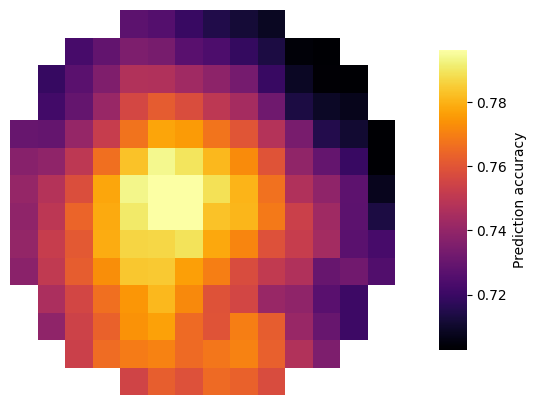

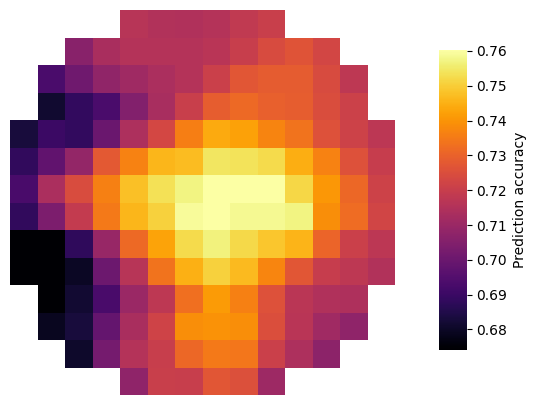

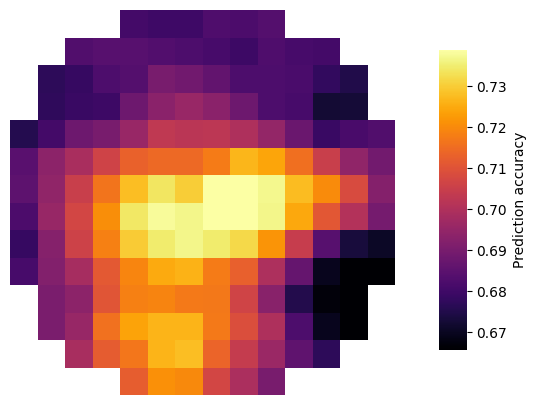

In [17]:
if tiny:
    settings = settings + '_tiny'

shelt = np.zeros((14,14))
pre = np.zeros((14,14))
post = np.zeros((14,14))
n_shelt = 0
n_pre = 0
n_post = 0
for sesh in pa.keys():
    if 'shelter_only' in pa[sesh].keys():
        shelt += pa[sesh]['shelter_only']
        n_shelt += 1
    elif 'shelter_present' in pa[sesh].keys():
        shelt += pa[sesh]['shelter_present']
        n_shelt += 1
    if 'barrier_pre_flip' in pa[sesh].keys():
        pre += pa[sesh]['barrier_pre_flip']
        n_pre += 1
    if 'barrier_post_flip' in pa[sesh].keys():
        post += pa[sesh]['barrier_post_flip']
        n_post += 1
shelt = shelt / n_shelt
pre = pre / n_pre
post = post / n_post

# shelter_only
fig,ax = plt.subplots(1,1,figsize = (7,5))
cbar_ax = fig.add_axes([0.85, 0.2, 0.04, 0.6])
ax = sns.heatmap(
        shelt,
        cmap="inferno",  # "coolwarm",
        cbar_ax=cbar_ax,
        robust=True,
        ax=ax,
        mask=(shelt == 0),
        cbar_kws={"label": "Prediction accuracy"},
        # norm=plt.Normalize(vmin=vmin, vmax=vmax),
    )
ax.axis("off")
ax.set_aspect("equal")
plt.savefig(save_path+'/'+str('shelter_only_avg_map_'+settings+'.png'))

# pre_flip
fig,ax = plt.subplots(1,1,figsize = (7,5))
cbar_ax = fig.add_axes([0.85, 0.2, 0.04, 0.6])
ax = sns.heatmap(
        pre,
        cmap="inferno",  # "coolwarm",
        cbar_ax=cbar_ax,
        robust=True,
        ax=ax,
        mask=(pre == 0),
        cbar_kws={"label": "Prediction accuracy"},
        # norm=plt.Normalize(vmin=vmin, vmax=vmax),
    )
ax.axis("off")
ax.set_aspect("equal")
plt.savefig(save_path+'/'+str('barrier_pre_flip_avg_map_'+settings+'.png'))

# post_flip
fig,ax = plt.subplots(1,1,figsize = (7,5))
cbar_ax = fig.add_axes([0.85, 0.2, 0.04, 0.6])
ax = sns.heatmap(
        post,
        cmap="inferno",  # "coolwarm",
        cbar_ax=cbar_ax,
        robust=True,
        ax=ax,
        mask=(post == 0),
        cbar_kws={"label": "Prediction accuracy"},
        # norm=plt.Normalize(vmin=vmin, vmax=vmax),
    )
ax.axis("off")
ax.set_aspect("equal")
plt.savefig(save_path+'/'+str('barrier_post_flip_avg_map_'+settings+'.png'))